<a href="https://colab.research.google.com/github/edgargalvao/Satellite-Image-Segmentation-UNET/blob/main/Classifing_RioClaro_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Satellite Imagery Data Preparation



Importing Libraries

In [ ]:
!pip install -U segmentation-models

In [ ]:
import os
import cv2
from PIL import Image
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd

from matplotlib import pyplot as plt
import random

import segmentation_models as sm

Segmentation Models: using `keras` framework.


Getting data

In [ ]:
#Mount your drive to import data
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Specify the path of thew dataset
!ls -lah '/content/drive/MyDrive/IC_2023_2024/'

ls: cannot access '/content/drive/MyDrive/IC_2023_2024/': No such file or directory


In [ ]:
dataset_root_folder = '/content/drive/MyDrive/IC_2023_2024'

In [ ]:
dataset_name = "Python"

In [ ]:
import scipy


Separate and associate images to the respective ground truth

In [ ]:
image_dataset_NIR = []
image_dataset_RGB = []
mask_dataset = []

for image_type in ['ImagemRGB', 'ImagemNIR','GroundTruth']:
  for image_name in ['CBERS04_RGB','CBERS04_NIR' , 'gt']:
    for image_id in range(0,168):

      if image_name == 'CBERS04_RGB':
        image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/{image_type}/{image_name}{image_id}.PNG',1)

      if image_name == 'CBERS04_NIR':
        image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/{image_type}/{image_name}{image_id}.PNG',1)

      if image_name == 'gt':
        image = cv2.imread(f'{dataset_root_folder}/{dataset_name}/{image_type}/Revisao/PNG/{image_name}{image_id}.PNG',1)

      if image is not None:
        if image_type == 'GroundTruth':
          image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
          mask_dataset.append(image)
        elif image_type == 'ImagemRGB':
          image_dataset_RGB.append(image)
        elif image_type == 'ImagemNIR':
          image_dataset_NIR.append(image)


In [ ]:
image_dataset_RGB = np.array(image_dataset_RGB)
image_dataset_NIR = np.array(image_dataset_NIR)
mask_dataset = np.array(mask_dataset)

166


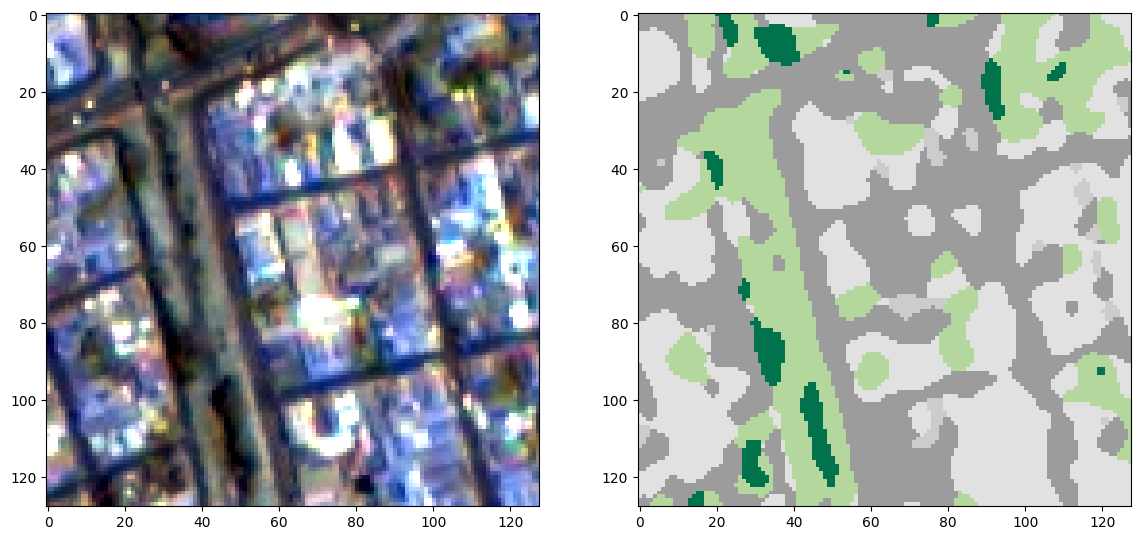

In [ ]:
#Here we can see that the associantion of the dataset RGB and Ground Truth is correct
random_image_id = random.randint(0, len(image_dataset_RGB))

plt.figure(figsize=(14,8))
plt.subplot(121)
plt.imshow(image_dataset_RGB[random_image_id])
#plt.subplot(12)
#plt.imshow(image_dataset_NIR[random_image_id])
plt.subplot(122)
plt.imshow(mask_dataset[random_image_id])
print(random_image_id)

166


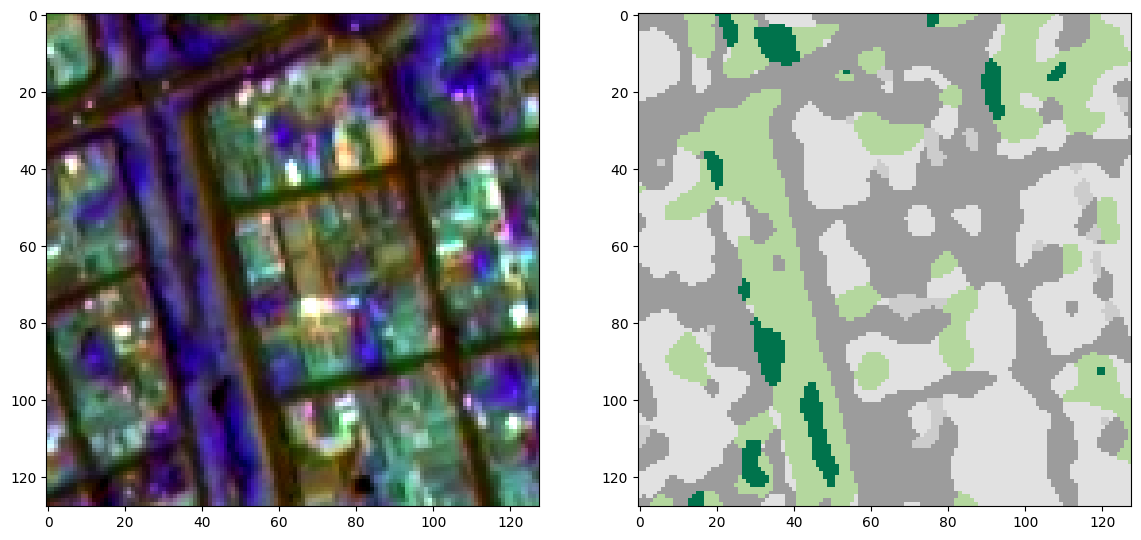

In [ ]:

plt.figure(figsize=(14,8))
#plt.subplot(121)
#plt.imshow(image_dataset_RGB[random_image_id])
plt.subplot(121)
plt.imshow(image_dataset_NIR[random_image_id])
plt.subplot(122)
plt.imshow(mask_dataset[random_image_id])
print(random_image_id)

# Defining Classes

Each class seen in the ground has an RGB code

In [ ]:
class_veg_arborea =[0, 115, 76]
class_veg_arborea = np.array(class_veg_arborea)
print(class_veg_arborea)

class_veg_rasteira=[180, 215, 158]
class_veg_rasteira= np.array(class_veg_rasteira)
print(class_veg_rasteira)

class_eucalipto = [76, 230, 0]
class_eucalipto = np.array(class_eucalipto)
print(class_eucalipto)

class_solo_exposto_escuro = [215,158, 158]
class_solo_exposto_escuro = np.array(class_solo_exposto_escuro)
print(class_solo_exposto_escuro)

class_solo_exposto_claro = [215, 194, 158]
class_solo_exposto_claro = np.array(class_solo_exposto_claro)
print(class_solo_exposto_claro)

class_edf_ceramica = [225, 225, 225]
class_edf_ceramica = np.array(class_edf_ceramica)
print(class_edf_ceramica)

class_edf_concreto = [204,204,204]
class_edf_concreto = np.array(class_edf_concreto)
print(class_edf_concreto)

class_edf_asfalto = [178,178,178]
class_edf_asfalto = np.array(class_edf_asfalto)
print(class_edf_asfalto)

class_edf_fibrocimento = [156,156,156]
class_edf_fibrocimento = np.array(class_edf_fibrocimento)
print(class_edf_fibrocimento)

class_sombra_edf = [245,122,182]
class_sombra_edf = np.array(class_sombra_edf)
print(class_sombra_edf)

class_agua_limpa = [122,182,245]
class_agua_limpa = np.array(class_agua_limpa)
print(class_agua_limpa)

class_agua_turva = [102, 153,205]
class_agua_turva = np.array(class_agua_turva)
print(class_agua_turva)

class_piscina = [122,142,245]
class_piscina = np.array(class_piscina)
print(class_piscina)

class_grama_sintetica = [85,255,0]
class_grama_sintetica = np.array(class_grama_sintetica)
print(class_grama_sintetica)

class_cemiterio = [245,245,122]
class_cemiterio = np.array(class_cemiterio)
print(class_cemiterio)

[  0 115  76]
[180 215 158]
[ 76 230   0]
[215 158 158]
[215 194 158]
[225 225 225]
[204 204 204]
[178 178 178]
[156 156 156]
[245 122 182]
[122 182 245]
[102 153 205]
[122 142 245]
[ 85 255   0]
[245 245 122]


In [ ]:
label = mask_dataset

rgb_to_label function sets for each rgb previously defined an id. Making a matrix of ids

In [ ]:
def rgb_to_label(label):
  label_segment = np.zeros(label.shape, dtype=np.uint8)
  label_segment[np.all(label == class_veg_arborea, axis=-1)] = 0
  label_segment[np.all(label == class_veg_rasteira, axis=-1)] = 1
  label_segment[np.all(label == class_eucalipto, axis=-1)] = 2
  label_segment[np.all(label == class_solo_exposto_escuro, axis=-1)] = 3
  label_segment[np.all(label == class_solo_exposto_claro, axis=-1)] = 4
  label_segment[np.all(label == class_edf_ceramica, axis=-1)] = 5
  label_segment[np.all(label == class_edf_concreto, axis=-1)] = 6
  label_segment[np.all(label == class_edf_asfalto, axis=-1)] = 7
  label_segment[np.all(label == class_edf_fibrocimento, axis=-1)] = 8
  label_segment[np.all(label == class_sombra_edf, axis=-1)] = 9
  label_segment[np.all(label == class_agua_limpa, axis=-1)] = 10
  label_segment[np.all(label == class_agua_turva, axis=-1)] = 11
  label_segment[np.all(label == class_piscina, axis=-1)] = 12
  label_segment[np.all(label == class_grama_sintetica, axis=-1)] = 13
  label_segment[np.all(label == class_cemiterio, axis=-1)] = 14

  #print(label_segment)
  label_segment = label_segment[:,:,0]
  print(label_segment)
  return label_segment

In [ ]:
#values = []
#for i in range(mask_dataset.shape[0]):
#  print(mask_dataset[i])

A saída de streaming foi truncada nas últimas 5000 linhas.
  [225 225 225]
  [225 225 225]]]
[[[180 215 158]
  [180 215 158]
  [180 215 158]
  ...
  [156 156 156]
  [156 156 156]
  [156 156 156]]

 [[180 215 158]
  [180 215 158]
  [180 215 158]
  ...
  [156 156 156]
  [156 156 156]
  [156 156 156]]

 [[180 215 158]
  [180 215 158]
  [180 215 158]
  ...
  [156 156 156]
  [156 156 156]
  [156 156 156]]

 ...

 [[225 225 225]
  [225 225 225]
  [225 225 225]
  ...
  [156 156 156]
  [  0 115  76]
  [  0 115  76]]

 [[225 225 225]
  [225 225 225]
  [225 225 225]
  ...
  [156 156 156]
  [156 156 156]
  [  0 115  76]]

 [[225 225 225]
  [225 225 225]
  [225 225 225]
  ...
  [156 156 156]
  [156 156 156]
  [  0 115  76]]]
[[[156 156 156]
  [156 156 156]
  [156 156 156]
  ...
  [180 215 158]
  [180 215 158]
  [180 215 158]]

 [[156 156 156]
  [156 156 156]
  [156 156 156]
  ...
  [180 215 158]
  [180 215 158]
  [180 215 158]]

 [[156 156 156]
  [156 156 156]
  [156 156 156]
  ...
  [180 215 158]

In [ ]:
labels = []
for i in range(mask_dataset.shape[0]):
  label = rgb_to_label(mask_dataset[i])
  labels.append(label)

[[8 8 8 ... 1 1 1]
 [8 8 8 ... 1 1 1]
 [8 8 8 ... 1 1 1]
 ...
 [8 8 8 ... 5 5 5]
 [8 8 8 ... 5 5 5]
 [8 8 8 ... 5 5 5]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [5 5 5 ... 1 1 1]
 [5 5 5 ... 1 1 1]
 [5 5 5 ... 1 1 1]]
[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 1 1 4]
 [1 1 1 ... 1 1 4]
 [1 1 1 ... 1 4 4]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[4 4 4 ... 1 1 1]
 [4 4 4 ... 1 1 1]
 [4 4 4 ... 1 1 1]
 ...
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]]
[[1 1 1 ... 8 0 0]
 [1 1 1 ... 8 0 0]
 [1 1 1 ... 8 0 0]
 ...
 [0 0 1 ... 1 1 1]
 [0 0 1 ... 1 1 1]
 [0 0 0 ... 1 1 1]]
[[0 1 1 ... 1 1 1]
 [0 0 1 ... 8 1 1]
 [0 0 1 ... 8 8 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 [1 1 1 ... 0 0 0]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [

In [ ]:
labels = np.array(labels)
labels = np.expand_dims(labels, axis=3)

In [ ]:
np.unique(labels)

array([ 0,  1,  2,  3,  4,  5,  6,  8,  9, 10, 11, 12, 14], dtype=uint8)

0


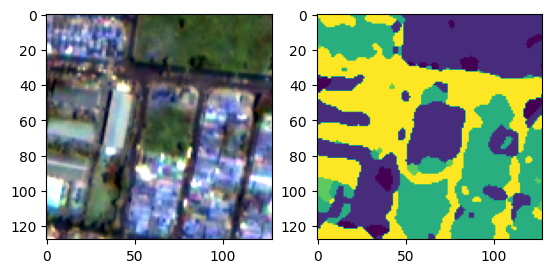

In [ ]:
random_image_id = random.randint(0, len(image_dataset_RGB))

plt.subplot(121)
plt.imshow(image_dataset_RGB[random_image_id])
plt.subplot(122)
plt.imshow(mask_dataset[random_image_id])
plt.imshow(labels[random_image_id][:,:,0])
print(random_image_id)

# Defining the Architecture

In [ ]:
from tensorflow.keras.utils import to_categorical


In [ ]:

labels_categorical_dataset = to_categorical(labels)

In [ ]:
master_training_dataset_RGB = image_dataset_RGB
master_training_dataset_NIR = image_dataset_NIR

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
labels_categorical_dataset.shape

(168, 128, 128, 15)

spliting our train set and test set for validation

In [ ]:
X_train_RGB, X_test_RGB, y_train_RGB, y_test_RGB = train_test_split(master_training_dataset_RGB , labels_categorical_dataset, test_size=0.15, random_state=100)

In [ ]:
X_train_NIR, X_test_NIR, y_train_NIR, y_test_NIR = train_test_split(master_training_dataset_NIR , labels_categorical_dataset, test_size=0.15, random_state=100)

In [ ]:
image_height = X_train_RGB.shape[1]
image_width = X_train_RGB.shape[2]
image_channels = X_train_RGB.shape[3]
total_classes = y_train_RGB.shape[3]

In [ ]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Conv2DTranspose
from keras.layers import concatenate, BatchNormalization, Dropout, Lambda

In [ ]:
from keras import backend as K

In [ ]:
def jaccard_coef(y_true, y_pred):
  y_true_flatten = K.flatten(y_true)
  y_pred_flatten = K.flatten(y_pred)
  intersection = K.sum(y_true_flatten * y_pred_flatten)
  final_coef_value = (intersection + 1.0) / (K.sum(y_true_flatten) + K.sum(y_pred_flatten) - intersection + 1.0)
  return final_coef_value


In [ ]:
def multi_unet_model(n_classes=15, image_height=128, image_width=128, image_channels=1):

  inputs = Input((image_height, image_width, image_channels))

  source_input = inputs

  c1 = Conv2D(8, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(source_input)
  c1 = Dropout(0.2)(c1)
  c1 = Conv2D(8, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c1)
  p1 = MaxPooling2D((2,2))(c1)

  c2 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p1)
  c2 = Dropout(0.2)(c2)
  c2 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c2)
  p2 = MaxPooling2D((2,2))(c2)

  c3 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p2)
  c3 = Dropout(0.2)(c3)
  c3 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c3)
  p3 = MaxPooling2D((2,2))(c3)

  c4 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p3)
  c4 = Dropout(0.2)(c4)
  c4 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c4)
  p4 = MaxPooling2D((2,2))(c4)

  c5 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(p4)
  c5 = Dropout(0.2)(c5)
  c5 = Conv2D(128, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c5)

  u6 = Conv2DTranspose(128, (2,2), strides=(2,2), padding="same")(c5)
  u6 = concatenate([u6, c4])
  c6 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u6)
  c6 = Dropout(0.2)(c6)
  c6 = Conv2D(64, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c6)

  u7 = Conv2DTranspose(32, (2,2), strides=(2,2), padding="same")(c6)
  u7 = concatenate([u7, c3])
  c7 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u7)
  c7 = Dropout(0.2)(c7)
  c7 = Conv2D(32, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c7)

  u8 = Conv2DTranspose(16, (2,2), strides=(2,2), padding="same")(c7)
  u8 = concatenate([u8, c2])
  c8 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u8)
  c8 = Dropout(0.2)(c8)
  c8 = Conv2D(16, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c8)

  u9 = Conv2DTranspose(8, (2,2), strides=(2,2), padding="same")(c8)
  u9 = concatenate([u9, c1], axis=3)
  c9 = Conv2D(8, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(u9)
  c9 = Dropout(0.2)(c9)
  c9 = Conv2D(8, (3,3), activation="relu", kernel_initializer="he_normal", padding="same")(c9)

  outputs = Conv2D(n_classes, (1,1), activation="softmax")(c9)

  model = Model(inputs=[inputs], outputs=[outputs])
  return model

In [ ]:
metrics = ["accuracy", jaccard_coef]

In [ ]:
def get_deep_learning_model():
  return multi_unet_model(n_classes=total_classes,
                          image_height=image_height,
                          image_width=image_width,
                          image_channels=image_channels)

In [ ]:
model = get_deep_learning_model()

In [ ]:
# Please uncomment this line to get model confiuration
model.get_config()

{'name': 'model',
 'trainable': True,
 'layers': [{'module': 'keras.layers',
   'class_name': 'InputLayer',
   'config': {'batch_input_shape': (None, 128, 128, 3),
    'dtype': 'float32',
    'sparse': False,
    'ragged': False,
    'name': 'input_1'},
   'registered_name': None,
   'name': 'input_1',
   'inbound_nodes': []},
  {'module': 'keras.layers',
   'class_name': 'Conv2D',
   'config': {'name': 'conv2d',
    'trainable': True,
    'dtype': 'float32',
    'filters': 8,
    'kernel_size': (3, 3),
    'strides': (1, 1),
    'padding': 'same',
    'data_format': 'channels_last',
    'dilation_rate': (1, 1),
    'groups': 1,
    'activation': 'relu',
    'use_bias': True,
    'kernel_initializer': {'module': 'keras.initializers',
     'class_name': 'HeNormal',
     'config': {'seed': None},
     'registered_name': None},
    'bias_initializer': {'module': 'keras.initializers',
     'class_name': 'Zeros',
     'config': {},
     'registered_name': None},
    'kernel_regularizer': No

## Generating Loss Function

- dice loss > Focal Loss > Total Loss
- Total Loss = (Dice loss + (1*Focal Loss))

In [ ]:
weights = [0.0666, 0.0666, 0.0666, 0.0666, 0.0666, 0.0666,0.0666,0.0666,0.0666,0.0666,0.0666,0.0666,0.0666,0.0666,0.0666]

In [ ]:
dice_loss = sm.losses.DiceLoss(class_weights = weights)

In [ ]:
focal_loss = sm.losses.CategoricalFocalLoss()

In [ ]:
total_loss = dice_loss + (1 * focal_loss)

## Model compilation

In [ ]:
import tensorflow as tf

In [ ]:
tf.keras.backend.clear_session()


In [ ]:
model_RGB = model
model_NIR = model

In [ ]:
model_RGB.compile(optimizer="adam", loss=total_loss, metrics=metrics)
model_NIR.compile(optimizer="adam", loss=total_loss, metrics=metrics)

In [ ]:
model_NIR.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 128, 128, 3)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 128, 128, 8)          224       ['input_1[0][0]']             
                                                                                                  
 dropout (Dropout)           (None, 128, 128, 8)          0         ['conv2d[0][0]']              
                                                                                                  
 conv2d_1 (Conv2D)           (None, 128, 128, 8)          584       ['dropout[0][0]']             
                                                                                              

In [ ]:
X_train_RGB.shape

(142, 128, 128, 3)

In [ ]:
model_history_RGB = model_RGB.fit(X_train_RGB, y_train_RGB,
                          batch_size=16,
                          verbose=1,
                          epochs=200,
                          validation_data=(X_test_RGB, y_test_RGB),
                          shuffle=False)

Epoch 1/200
9/9 [==============================] - 8s 151ms/step - loss: 1.1439 - accuracy: 0.1365 - jaccard_coef: 0.0732 - val_loss: 1.0713 - val_accuracy: 0.1649 - val_jaccard_coef: 0.0856
Epoch 2/200
9/9 [==============================] - 1s 64ms/step - loss: 1.0746 - accuracy: 0.1710 - jaccard_coef: 0.0897 - val_loss: 1.0388 - val_accuracy: 0.2568 - val_jaccard_coef: 0.0629
Epoch 3/200
9/9 [==============================] - 0s 53ms/step - loss: 1.0416 - accuracy: 0.2387 - jaccard_coef: 0.0581 - val_loss: 1.0355 - val_accuracy: 0.2938 - val_jaccard_coef: 0.0402
Epoch 4/200
9/9 [==============================] - 1s 61ms/step - loss: 1.0358 - accuracy: 0.3001 - jaccard_coef: 0.0403 - val_loss: 1.0353 - val_accuracy: 0.2875 - val_jaccard_coef: 0.0382
Epoch 5/200
9/9 [==============================] - 0s 53ms/step - loss: 1.0346 - accuracy: 0.3023 - jaccard_coef: 0.0455 - val_loss: 1.0339 - val_accuracy: 0.3006 - val_jaccard_coef: 0.0441
Epoch 6/200
9/9 [==============================] 

In [ ]:
model_history_NIR = model_NIR.fit(X_train_NIR, y_train_NIR,
                          batch_size=16,
                          verbose=1,
                          epochs=200,
                          validation_data=(X_test_NIR, y_test_NIR),
                          shuffle=False)

Epoch 1/200
9/9 [==============================] - 1s 69ms/step - loss: 1.0369 - accuracy: 0.2496 - jaccard_coef: 0.1200 - val_loss: 1.0134 - val_accuracy: 0.4393 - val_jaccard_coef: 0.1714
Epoch 2/200
9/9 [==============================] - 1s 59ms/step - loss: 1.0114 - accuracy: 0.5009 - jaccard_coef: 0.2287 - val_loss: 1.0087 - val_accuracy: 0.4776 - val_jaccard_coef: 0.2340
Epoch 3/200
9/9 [==============================] - 1s 59ms/step - loss: 1.0082 - accuracy: 0.5008 - jaccard_coef: 0.2504 - val_loss: 1.0055 - val_accuracy: 0.5432 - val_jaccard_coef: 0.2902
Epoch 4/200
9/9 [==============================] - 1s 57ms/step - loss: 1.0042 - accuracy: 0.5940 - jaccard_coef: 0.3278 - val_loss: 1.0023 - val_accuracy: 0.5959 - val_jaccard_coef: 0.3204
Epoch 5/200
9/9 [==============================] - 0s 55ms/step - loss: 1.0010 - accuracy: 0.6331 - jaccard_coef: 0.3388 - val_loss: 1.0012 - val_accuracy: 0.5646 - val_jaccard_coef: 0.2952
Epoch 6/200
9/9 [==============================] -

In [ ]:
history_a_RGB = model_history_RGB
#history_a_RGB.history


In [ ]:
history_a_NIR = model_history_NIR
#history_a_NIR.history

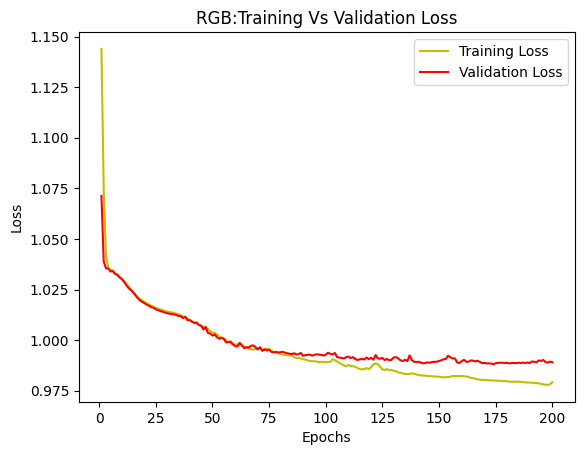

In [ ]:
path = '/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_RGB2/'

loss = history_a_RGB.history['loss']
val_loss = history_a_RGB.history['val_loss']
epochs = range(1, len(loss) + 1)

#plt.subplot(121)
plt.plot(epochs, loss, 'y', label="Training Loss")
plt.plot(epochs, val_loss, 'r', label="Validation Loss")
plt.title("RGB:Training Vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()



plt.savefig(f'{path}RGB_traning_vs_validationLoss.png')


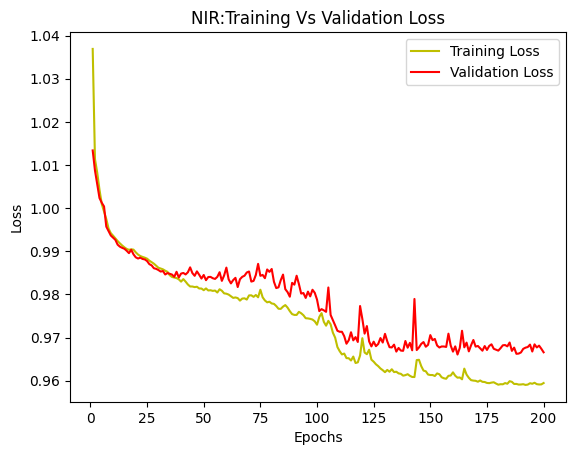

In [ ]:
path = '/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_NIR2/'

loss = history_a_NIR.history['loss']
val_loss = history_a_NIR.history['val_loss']
epochs = range(1, len(loss) + 1)

#plt.subplot(121)
plt.plot(epochs, loss, 'y', label="Training Loss")
plt.plot(epochs, val_loss, 'r', label="Validation Loss")
plt.title("NIR:Training Vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.savefig(f'{path}NIR_traning_vs_validationLoss.png')

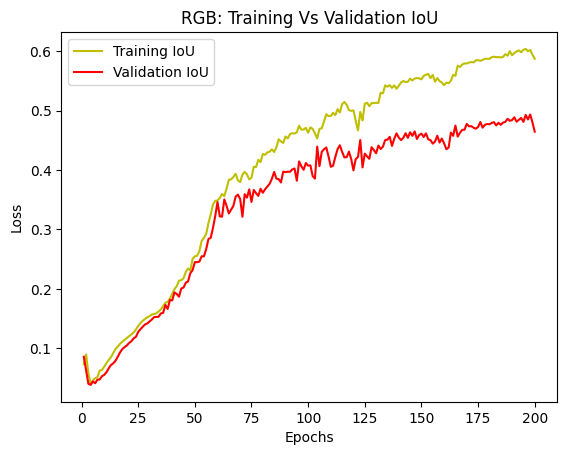

In [ ]:
path = '/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_RGB2/'

jaccard_coef_RGB = history_a_RGB.history['jaccard_coef']
val_jaccard_coef_RGB = history_a_RGB.history['val_jaccard_coef']

epochs = range(1, len(jaccard_coef_RGB) + 1)

plt.plot(epochs, jaccard_coef_RGB, 'y', label="Training IoU")
plt.plot(epochs, val_jaccard_coef_RGB, 'r', label="Validation IoU")
plt.title("RGB: Training Vs Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig(f'{path}RGB_traning_vs_validationIoU.png')




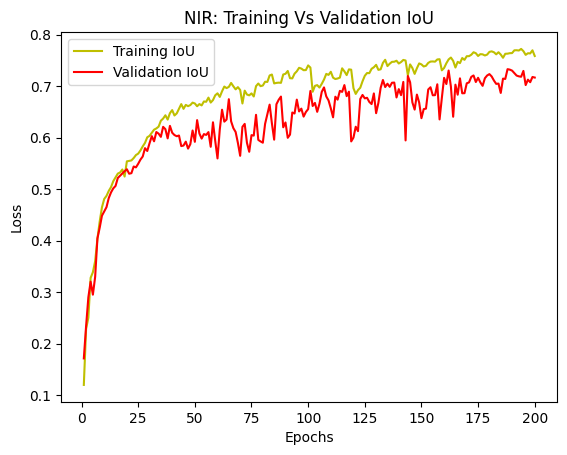

In [ ]:
path = '/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_NIR2/'
jaccard_coef_NIR = history_a_NIR.history['jaccard_coef']
val_jaccard_coef_NIR = history_a_NIR.history['val_jaccard_coef']

epochs = range(1, len(jaccard_coef_RGB) + 1)

plt.plot(epochs, jaccard_coef_NIR, 'y', label="Training IoU")
plt.plot(epochs, val_jaccard_coef_NIR, 'r', label="Validation IoU")
plt.title("NIR: Training Vs Validation IoU")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.savefig(f'{path}NIR_traning_vs_validationIoU.png')

In [ ]:
model_history_RGB.params
model_history_NIR.params

{'verbose': 1, 'epochs': 200, 'steps': 9}

In [ ]:
X_test_RGB

array([[[[ 20,  26,   5],
         [ 31,  36,   9],
         [ 13,  22,   4],
         ...,
         [ 39,  47,  18],
         [ 34,  42,  16],
         [ 31,  38,  14]],

        [[  7,  14,   0],
         [ 24,  29,   7],
         [ 29,  34,  10],
         ...,
         [ 41,  47,  18],
         [ 39,  45,  17],
         [ 34,  39,  15]],

        [[ 10,  14,   1],
         [ 15,  18,   3],
         [ 24,  26,   7],
         ...,
         [ 29,  35,  12],
         [ 30,  35,  13],
         [ 34,  37,  15]],

        ...,

        [[ 26,  33,  12],
         [ 34,  37,  15],
         [ 40,  40,  16],
         ...,
         [ 49,  66,  72],
         [ 43,  55,  62],
         [ 63,  67,  63]],

        [[ 17,  26,   8],
         [ 23,  30,  10],
         [ 34,  37,  13],
         ...,
         [ 46,  61,  62],
         [ 55,  66,  60],
         [ 59,  65,  52]],

        [[ 23,  32,   9],
         [ 17,  26,   7],
         [ 24,  31,   9],
         ...,
         [ 53,  66,  59],
        

In [ ]:
y_pred_RGB = model.predict(X_test_RGB)
y_pred_NIR = model.predict(X_test_NIR)

1/1 [==============================] - 0s 29ms/step


In [ ]:
y_pred_NIR

array([[[[8.83274376e-01, 7.95666054e-02, 3.06791067e-02, ...,
          1.07759743e-21, 6.63151266e-24, 1.96435945e-12],
         [9.38751161e-01, 5.68643063e-02, 4.27030912e-03, ...,
          1.90071444e-34, 1.27017790e-35, 2.25152152e-19],
         [9.45883989e-01, 5.37576601e-02, 3.42565501e-04, ...,
          0.00000000e+00, 0.00000000e+00, 1.58046654e-22],
         ...,
         [9.27391350e-01, 6.48561493e-02, 7.67542794e-03, ...,
          1.73758800e-35, 3.87210336e-35, 2.03495271e-19],
         [8.91589761e-01, 1.01969041e-01, 6.19004248e-03, ...,
          7.99658526e-30, 5.07038975e-30, 1.05976294e-15],
         [8.03905308e-01, 1.28782079e-01, 6.59723356e-02, ...,
          5.99981765e-21, 1.06117915e-19, 2.12531409e-10]],

        [[9.25887048e-01, 5.02315834e-02, 2.31088083e-02, ...,
          2.84116119e-30, 1.64177346e-31, 1.43482286e-17],
         [9.73906815e-01, 2.49941479e-02, 1.09288795e-03, ...,
          0.00000000e+00, 0.00000000e+00, 3.17293347e-28],
        

In [ ]:
y_pred_RGB

array([[[[1.19904138e-01, 1.14873119e-01, 9.50113987e-04, ...,
          4.72742245e-12, 4.26443899e-16, 1.79896160e-05],
         [4.15191017e-02, 1.01958059e-01, 2.40142108e-05, ...,
          7.93465419e-16, 2.99615501e-21, 1.05368088e-06],
         [2.21019723e-02, 7.39150569e-02, 5.43810302e-06, ...,
          2.57175423e-15, 1.52681062e-21, 3.19242349e-06],
         ...,
         [1.77303851e-02, 6.85803667e-02, 3.38086102e-06, ...,
          2.20708217e-13, 7.59458237e-20, 2.99189833e-05],
         [2.66069192e-02, 7.61604086e-02, 1.72820237e-05, ...,
          3.38742624e-13, 1.12677530e-18, 2.07359371e-05],
         [8.73704553e-02, 9.97192189e-02, 1.68518210e-03, ...,
          1.15125243e-09, 7.45983407e-13, 1.82052958e-04]],

        [[7.68334866e-02, 9.99284238e-02, 4.26174411e-05, ...,
          9.07633986e-17, 4.49143794e-23, 3.62383133e-07],
         [1.38839269e-02, 6.92942291e-02, 8.55188844e-08, ...,
          1.13481832e-22, 8.65965588e-32, 4.73661954e-09],
        

In [ ]:
y_pred_argmax_RGB = np.argmax(y_pred_RGB, axis=3)
y_pred_argmax_NIR = np.argmax(y_pred_NIR, axis=3)

In [ ]:
y_pred_RGB.shape

(26, 128, 128, 15)

In [ ]:
len(y_pred_argmax_RGB)

26

In [ ]:
y_pred_argmax_RGB
y_pred_argmax_NIR

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1],
        [0, 0, 0, ..., 1, 1, 1]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0],
        [0, 1, 1, ..., 0, 0, 0]],

       [[5, 5, 5, ..., 8, 8, 0],
        [5, 5, 5, ..., 8, 8, 0],
        [5, 5, 5, ..., 8, 8, 0],
        ...,
        [0, 0, 1, ..., 8, 8, 8],
        [0, 0, 1, ..., 8, 8, 8],
        [0, 0, 0, ..., 8, 8, 8]],

       ...,

       [[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [8, 8, 8, ..., 4, 4, 4],
        [8, 8, 8, ..., 4, 4, 4],
        [8, 8, 8, ..., 4, 4, 4]],

       [[8, 8, 8, ..., 5, 5, 5],
        [1, 1, 1, ..., 5, 5, 5],
        [1, 1, 1, ..., 5, 5, 5],
        ...,
        [8, 8, 8, ..., 

In [ ]:
y_test_argmax_RGB = np.argmax(y_test_RGB, axis=3)
y_test_argmax_NIR = np.argmax(y_test_NIR, axis=3)

In [ ]:
len(y_test_argmax_RGB)

26

## Comparing prediction results
-  using test images using mask images and predicted result images..

In [ ]:
import random


In [ ]:
def label_to_rgb(predicted_image):
  class_veg_arborea =[0, 115, 76]
  class_veg_arborea = np.array(class_veg_arborea)

  class_veg_rasteira=[180, 215, 158]
  class_veg_rasteira= np.array(class_veg_rasteira)

  class_eucalipto = [76, 230, 0]
  class_eucalipto = np.array(class_eucalipto)

  class_solo_exposto_escuro = [215,158, 158]
  class_solo_exposto_escuro = np.array(class_solo_exposto_escuro)

  class_solo_exposto_claro = [215, 194, 158]
  class_solo_exposto_claro = np.array(class_solo_exposto_claro)

  class_edf_ceramica = [225, 225, 225]
  class_edf_ceramica = np.array(class_edf_ceramica)

  class_edf_concreto = [204,204,204]
  class_edf_concreto = np.array(class_edf_concreto)

  class_edf_asfalto = [178,178,178]
  class_edf_asfalto = np.array(class_edf_asfalto)

  class_edf_fibrocimento = [156,156,156]
  class_edf_fibrocimento = np.array(class_edf_fibrocimento)

  class_sombra_edf = [245,122,182]
  class_sombra_edf = np.array(class_sombra_edf)

  class_agua_limpa = [122,182,245]
  class_agua_limpa = np.array(class_agua_limpa)

  class_agua_turva = [102, 153,205]
  class_agua_turva = np.array(class_agua_turva)

  class_piscina = [122,142,245]
  class_piscina = np.array(class_piscina)

  class_grama_sintetica = [85,255,0]
  class_grama_sintetica = np.array(class_grama_sintetica)

  class_cemiterio = [245,245,122]
  class_cemiterio = np.array(class_cemiterio)

  segmented_img = np.empty((predicted_image.shape[0], predicted_image.shape[1], 3))

  segmented_img[(predicted_image == 0)] = class_veg_arborea
  segmented_img[(predicted_image == 1)] = class_veg_rasteira
  segmented_img[(predicted_image == 2)] = class_eucalipto
  segmented_img[(predicted_image == 3)] = class_solo_exposto_escuro
  segmented_img[(predicted_image == 4)] = class_solo_exposto_claro
  segmented_img[(predicted_image == 5)] = class_edf_ceramica
  segmented_img[(predicted_image == 6)] = class_edf_concreto
  segmented_img[(predicted_image == 7)] = class_edf_asfalto
  segmented_img[(predicted_image == 8)] = class_edf_fibrocimento
  segmented_img[(predicted_image == 9)] = class_sombra_edf
  segmented_img[(predicted_image == 10)] = class_agua_limpa
  segmented_img[(predicted_image == 11)] = class_agua_turva
  segmented_img[(predicted_image == 12)] = class_piscina
  segmented_img[(predicted_image == 13)] = class_grama_sintetica
  segmented_img[(predicted_image == 14)] = class_cemiterio

  segmented_img = segmented_img.astype(np.uint8)
  return(segmented_img)

In [ ]:

test_image_number = random.randint(0, len(X_test_RGB))

test_image = X_test_RGB[test_image_number]
ground_truth_image = y_test_argmax_RGB[test_image_number]

test_image_input = np.expand_dims(test_image, 0)

prediction = model.predict(test_image_input)
predicted_image = np.argmax(prediction, axis=3)
predicted_image = predicted_image[0,:,:]


test_image_NIR = X_test_NIR[test_image_number]
ground_truth_image_NIR = y_test_argmax_NIR[test_image_number]

test_image_input_NIR = np.expand_dims(test_image_NIR, 0)

prediction_NIR = model.predict(test_image_input_NIR)
predicted_image_NIR = np.argmax(prediction_NIR, axis=3)
predicted_image_NIR = predicted_image_NIR[0,:,:]



1/1 [==============================] - 0s 29ms/step


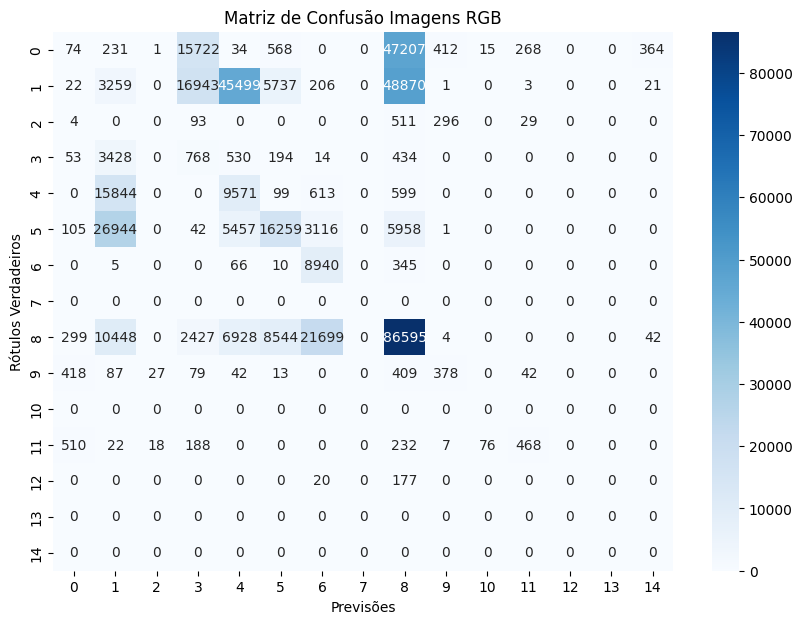

In [ ]:

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns


cm = confusion_matrix(y_test_argmax_RGB.flatten(), y_pred_argmax_RGB.flatten(), labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])

#print(cm)


plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14], yticklabels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
plt.xlabel("Previsões")
plt.ylabel("Rótulos Verdadeiros")
plt.title("Matriz de Confusão Imagens RGB")

path = '/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_RGB2/'
plt.savefig(f'{path}RGB_Matriz_confusao.png')

plt.show()


In [ ]:

precision = precision_score(y_test_argmax_RGB.flatten(), y_pred_argmax_RGB.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )
print('Precision Score:')
print(precision)

recall = recall_score(y_test_argmax_RGB.flatten(), y_pred_argmax_RGB.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )
print('Recall Score:')
print(recall)

f1 = f1_score(y_test_argmax_RGB.flatten(), y_pred_argmax_RGB.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )
print('F1 Score:')
print(f1)

width = 0.25
x = np.arange(len([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]))

fig, ax = plt.subplots(figsize=(14, 6))

bar1 = ax.bar(x - width, precision, width, label='Precisão', color='b')
bar2 = ax.bar(x, recall, width, label='Recall', color='r')
bar3 = ax.bar(x + width, f1, width, label='F1-Score', color='g')

# Adicionar títulos e rótulos
ax.set_xlabel('Classes')
ax.set_ylabel('Métricas')
ax.set_title('RGB: Precisão, Recall e F1-Score por Classe')
ax.set_xticks(x)
ax.set_xticklabels([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
ax.legend()

# Adicionar rótulos de valores nas barras
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points de deslocamento
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Métricas")

plt.show()
fig.savefig(f'{path}RGB_precision_recall_F1.png')


'\nprecision = precision_score(y_test_argmax_RGB.flatten(), y_pred_argmax_RGB.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )\nprint(\'Precision Score:\')\nprint(precision)\n\nrecall = recall_score(y_test_argmax_RGB.flatten(), y_pred_argmax_RGB.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )\nprint(\'Recall Score:\')\nprint(recall)\n\nf1 = f1_score(y_test_argmax_RGB.flatten(), y_pred_argmax_RGB.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )\nprint(\'F1 Score:\')\nprint(f1)\n\nwidth = 0.25\nx = np.arange(len([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]))\n\nfig, ax = plt.subplots(figsize=(14, 6))\n\nbar1 = ax.bar(x - width, precision, width, label=\'Precisão\', color=\'b\')\nbar2 = ax.bar(x, recall, width, label=\'Recall\', color=\'r\')\nbar3 = ax.bar(x + width, f1, width, label=\'F1-Score\', color=\'g\')\n\n# Adicionar títulos e rótulos\nax.set_xlabel(\'Classes\')\nax.set_ylabel(\'Métricas\')\nax.set_title(\'RGB: Precisão, Reca

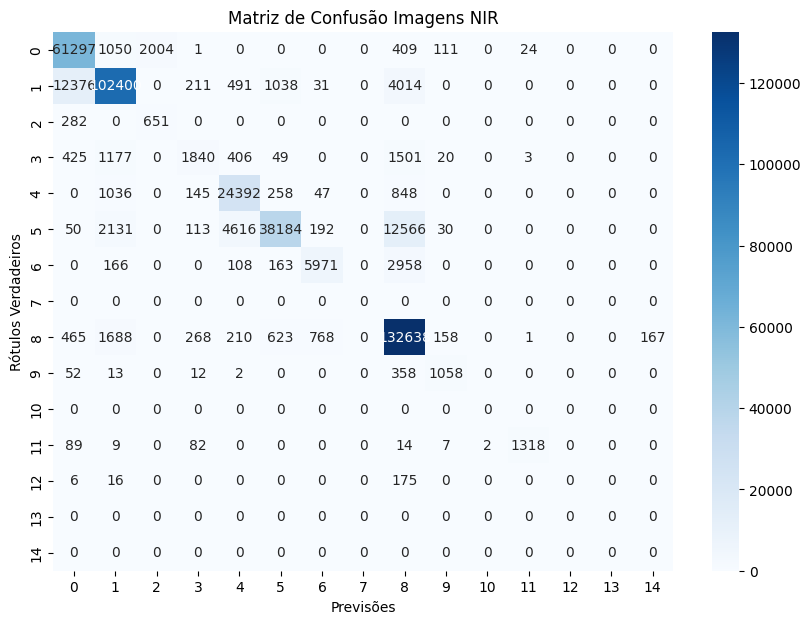

In [ ]:
cm = confusion_matrix(y_test_argmax_NIR.flatten(), y_pred_argmax_NIR.flatten(), labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])

#print(cm)


plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14], yticklabels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
plt.xlabel("Previsões")
plt.ylabel("Rótulos Verdadeiros")
plt.title("Matriz de Confusão Imagens NIR")

path = '/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_NIR2/'
plt.savefig(f'{path}NIR_Matriz_confusao.png')
plt.show()


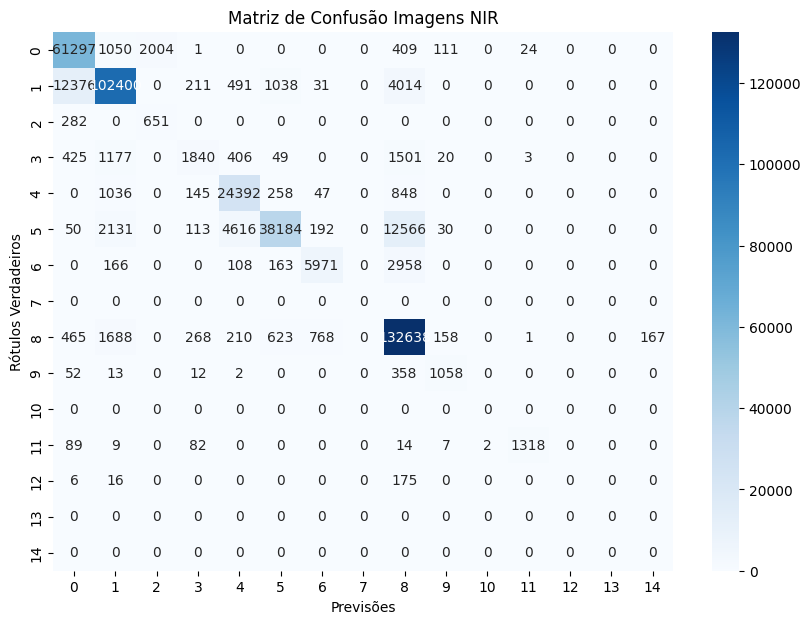

'\nprecision = precision_score(y_test_argmax_NIR.flatten(), y_pred_argmax_NIR.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )\nprint(\'Precision Score:\')\nprint(precision)\n\nrecall = recall_score(y_test_argmax_NIR.flatten(), y_pred_argmax_NIR.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )\nprint(\'Recall Score:\')\nprint(recall)\n\nf1 = f1_score(y_test_argmax_NIR.flatten(), y_pred_argmax_NIR.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )\nprint(\'F1 Score:\')\nprint(f1)\n\nwidth = 0.25\nx = np.arange(len([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]))\n\nfig, ax = plt.subplots(figsize=(14,6))\n\nbar1 = ax.bar(x - width, precision, width, label=\'Precisão\', color=\'b\')\nbar2 = ax.bar(x, recall, width, label=\'Recall\', color=\'r\')\nbar3 = ax.bar(x + width, f1, width, label=\'F1-Score\', color=\'g\')\n\n# Adicionar títulos e rótulos\nax.set_xlabel(\'Classes\')\nax.set_ylabel(\'Métricas\')\nax.set_title(\'NIR: Precisão, Recal

<Figure size 640x480 with 0 Axes>

In [ ]:

'''
precision = precision_score(y_test_argmax_NIR.flatten(), y_pred_argmax_NIR.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )
print('Precision Score:')
print(precision)

recall = recall_score(y_test_argmax_NIR.flatten(), y_pred_argmax_NIR.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )
print('Recall Score:')
print(recall)

f1 = f1_score(y_test_argmax_NIR.flatten(), y_pred_argmax_NIR.flatten(), average=None,labels=[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14] )
print('F1 Score:')
print(f1)

width = 0.25
x = np.arange(len([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14]))

fig, ax = plt.subplots(figsize=(14,6))

bar1 = ax.bar(x - width, precision, width, label='Precisão', color='b')
bar2 = ax.bar(x, recall, width, label='Recall', color='r')
bar3 = ax.bar(x + width, f1, width, label='F1-Score', color='g')

# Adicionar títulos e rótulos
ax.set_xlabel('Classes')
ax.set_ylabel('Métricas')
ax.set_title('NIR: Precisão, Recall e F1-Score por Classe')
ax.set_xticks(x)
ax.set_xticklabels([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14])
ax.legend()

# Adicionar rótulos de valores nas barras
def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points de deslocamento
                    textcoords="offset points",
                    ha='center', va='bottom')

add_labels(bar1)
add_labels(bar2)
add_labels(bar3)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title="Métricas")

plt.show()
fig.savefig(f'{path}NIR_precision_recall_F1.png')
'''

In [ ]:
path = '/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_RGB2/pi_'
for i in range(0, len(image_dataset_RGB)+1):
  image_i = image_dataset_RGB[i]
  image_input_i = np.expand_dims(image_i, 0)

  prediction_i = model.predict(image_input_i)
  predicted_image_i = np.argmax(prediction_i, axis=3)
  predicted_image_i = predicted_image_i[0,:,:]
  image_i = Image.fromarray(label_to_rgb(predicted_image_i))
  image_i.save(f'{path}{i}.png')


1/1 [==============================] - 0s 18ms/step


In [ ]:
path = '/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_NIR2/pi_'
for i in range(0, len(image_dataset_NIR)+1):
  image_i = image_dataset_NIR[i]
  image_input_i = np.expand_dims(image_i, 0)

  prediction_i = model.predict(image_input_i)
  predicted_image_i = np.argmax(prediction_i, axis=3)
  predicted_image_i = predicted_image_i[0,:,:]
  image_i = Image.fromarray(label_to_rgb(predicted_image_i))
  image_i.save(f'{path}{i}.png')

1/1 [==============================] - 0s 19ms/step


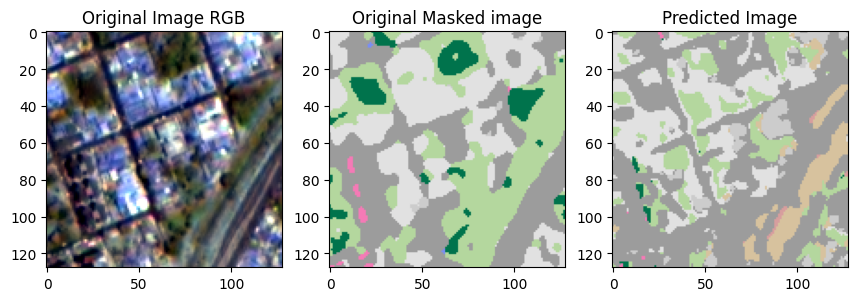

In [ ]:

plt.figure(figsize=(14,8))
plt.subplot(241)
plt.title("Original Image RGB")
plt.imshow(test_image)
plt.subplot(242)
plt.title("Original Masked image")
plt.imshow(label_to_rgb(ground_truth_image))
plt.subplot(243)
plt.title("Predicted Image")
plt.imshow(label_to_rgb(predicted_image))


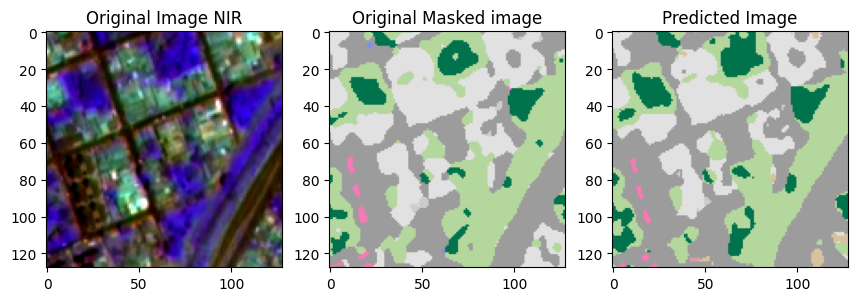

In [ ]:

plt.figure(figsize=(14,8))
plt.subplot(241)
plt.title("Original Image NIR")
plt.imshow(test_image_NIR)
plt.subplot(242)
plt.title("Original Masked image")
plt.imshow(label_to_rgb(ground_truth_image_NIR))
plt.subplot(243)
plt.title("Predicted Image")
plt.imshow(label_to_rgb(predicted_image_NIR))

In [ ]:
type(label_to_rgb(predicted_image))

numpy.ndarray

In [ ]:
model_RGB.save("/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_RGB2/satellite_segmentation_full.h5")
model_NIR.save("/content/drive/MyDrive/IC_2023_2024/Python/PredictedImages_200epochs_NIR2/satellite_segmentation_full.h5")

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
!ls -lah

total 24K
drwxr-xr-x 3 root root 4.0K Jun  6 19:57 "'"
drwxr-xr-x 1 root root 4.0K Jun  6 19:57  .
drwxr-xr-x 1 root root 4.0K Jun  6 19:25  ..
drwxr-xr-x 4 root root 4.0K Jun  5 13:29  .config
drwx------ 7 root root 4.0K Jun  6 19:28  drive
drwxr-xr-x 1 root root 4.0K Jun  5 13:35  sample_data
